In [1]:
import torch
import torch.autograd as autograd         # computation graph
from torch import Tensor                  # tensor node in the computation graph
import torch.nn as nn                     # neural networks
import torch.optim as optim               # optimizers e.g. gradient descent, ADAM, etc.
from torch.nn.parameter import Parameter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.ticker


import numpy as np
import time
# from pyDOE import lhs         #Latin Hypercube Sampling
import scipy.io

from smt.sampling_methods import LHS
from scipy.io import loadmat,savemat




#Set default dtype to float32
torch.set_default_dtype(torch.float)

#PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device2 = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')

print("Device 1: ",device)
# print("Device 2: ",device2)

Device 1:  cuda:0


In [2]:
R0 = 5.34 #mm 5.34
Rs = 19 #mm
mu_vis = 0.3 
mu = 0.3 #Friction Coefficient (not viscosity)
delta = 0.5
A = 6.41 #For slip factor
pi = np.pi
Omega = 300 #rpm
V = 2 #mm/s
F = 0.67 #mm
rho = 2700 * 1e-6 #g/mm3
k_B = 1.380649*1e-23 #J/K
R = 8.314 #J/(K.mol)
E_a = 205000 #J/mol #Q
alpha_sig = 52 #mm^2/N
# A = np.exp(27.78)
log_A = 27.78
n = 3.49
k = 0.167 #Thermal Conductivity #W/(mmK)
c_p = 0.897 #J/gK 
alpha_m = k/(rho*c_p)
T_a = 298.0


k_t = 0.0176 #W/(mmK)
c_p_t = 0.46 #J/gk
rho_t = 2700 * 1e-6 #g/mm3
alpha_t = k_t/(rho_t*c_p_t)

h_sides = 5*1e-6 #W/mm^2K
C_bot = 0.15*1e-6 #W/mm^2K^3

eeta = alpha_m/(alpha_m+alpha_t)

lb_xyz_uvw = np.array([-20.0,-20.0,-3.0])
ub_xyz_uvw = np.array([20.0,20.0,0.0])


lb_xyz = np.array([-50.0,-20.0,-3.0])
ub_xyz = np.array([50.0,20.0,0.0])



In [3]:
def train_step(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat):
    # def closure():
    optimizer.zero_grad()
    #model_PINN.zero_grad()
    loss_total = model_PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat)
    loss_total.backward()
    # loss_T.backward()

        # return loss

    optimizer.step()

In [4]:
def train_model(max_iter,rep,n_batches):
    print(rep)
    torch.manual_seed(rep*123)
    start_time = time.time()
    thresh_flag = 0

    xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot, uvw_true_top,r_fr_ph_out = trainingdata_uvw(N_B,N_f,lb_xyz,ub_xyz,rep*123)
    xyz_coll = torch.from_numpy(xyz_coll).float().to(device)
    xyz_1 = torch.from_numpy(xyz_1).float().to(device)
    xyz_2 = torch.from_numpy(xyz_2).float().to(device)
    xyz_3 = torch.from_numpy(xyz_3).float().to(device)
    xyz_4 = torch.from_numpy(xyz_4).float().to(device)
    r_fr_ph_out = torch.from_numpy(r_fr_ph_out).float()
    
    xyz_top = torch.from_numpy(xyz_top).float().to(device)
    xyz_bot = torch.from_numpy(xyz_bot).float().to(device)
   
    uvw_true_top = torch.from_numpy(uvw_true_top).float().to(device)
    f_hat = torch.zeros(xyz_coll.shape[0],1).to(device)
    N_hat = torch.zeros(xyz_top.shape[0],1).to(device)

    train_loss = []
    
    train_step(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat)
        # loss_np = PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat).cpu().detach().numpy()
        # print(i,"Train Loss",train_loss[-1],"Test MSE",test_mse_loss[-1],"Test RE",test_re_loss[-1])
    loss_np = model_PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat).cpu().detach().numpy()
    print(0,"Train Loss",loss_np)
    train_loss.append(loss_np)
    
    #pretrain
    # for i in range(50):
    #     optimizer.zero_grad()
    #     loss_pretrain = model_PINN.pretrain_T_loss(xyz_coll)
    #     loss_pretrain.backward()
    #     optimizer.step()
        
    # print("Pretrained with T = 300.0")
    
    #Batching only Collocation and f_hat for now
    
    # batch_size_coll = int(xyz_coll.shape[0]/n_batches)
    # batch_size_top = int(xyz_top.shape[0]/n_batches)

    # batch_size_sides = int(xyz_1.shape[0]/n_batches)
    # batch_size_bot = int(xyz_bot.shape[0]/n_batches)

    # xyz_coll_batches = torch.split(xyz_coll,batch_size_coll)
    # f_hat_batches = torch.split(f_hat,batch_size_coll)
    
    # xyz_top_batches = torch.split(xyz_top,batch_size_top)
    # N_hat_batches = torch.split(N_hat,batch_size_top)

    # xyz_1_batches = torch.split(xyz_1,batch_size_sides)
    # xyz_2_batches = torch.split(xyz_2,batch_size_sides)
    # xyz_3_batches = torch.split(xyz_3,batch_size_sides)
    # xyz_4_batches = torch.split(xyz_4,batch_size_sides)
    
    # xyz_bot_batches = torch.split(xyz_4,batch_size_bot)

    # uvw_true_top_batches = torch.split(uvw_true_top,batch_size_top)
    # r_fr_ph_out_batches = torch.split(r_fr_ph_out,batch_size_top)
    


    
    for i in range(max_iter):
#         if(i>0 and i%50==0):
#             _,_,_,_,_,xyz_top,xyz_bot = trainingdata(N_B,N_f,i*123)
#             # xyz_coll = torch.from_numpy(xyz_coll).float().to(device)
#             # xyz_1 = torch.from_numpy(xyz_1).float().to(device)
#             # xyz_2 = torch.from_numpy(xyz_2).float().to(device)
#             # xyz_3 = torch.from_numpy(xyz_3).float().to(device)
#             # xyz_4 = torch.from_numpy(xyz_4).float().to(device)

#             xyz_top = torch.from_numpy(xyz_top).float().to(device)
#             xyz_bot = torch.from_numpy(xyz_bot).float().to(device)

        # optimizer.zero_grad()
        # for b in range(n_batches):
        #     loss_uvw,loss_T = model_PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat,uvw_true_top,r_fr_ph_out)
        #     loss_uvw.backward()
        #     loss_T.backward()

        # optimizer.step()
        
        # train_step(xyz_coll_batches[b],xyz_1_batches[b], xyz_2_batches[b], xyz_3_batches[b], xyz_4_batches[b],xyz_top_batches[b],xyz_bot_batches[b],f_hat_batches[b],N_hat_batches[b],uvw_true_top_batches[b],r_fr_ph_out_batches[b])
            

        train_step(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat)
        # loss_np = PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat).cpu().detach().numpy()
        # print(i,"Train Loss",train_loss[-1],"Test MSE",test_mse_loss[-1],"Test RE",test_re_loss[-1])
        loss_np = model_PINN.loss(xyz_coll,xyz_1, xyz_2, xyz_3, xyz_4,xyz_top,xyz_bot,f_hat,N_hat).cpu().detach().numpy()
        print(i,"Train Loss",loss_np)
        train_loss.append(loss_np)

        # if(i>0 and i%25 ==0):
        #   pretrain(xyt_DBC,p_iters)


    elapsed_time[rep] = time.time() - start_time
    print('Training time: %.2f' % (elapsed_time[rep]))

    return train_loss

In [5]:
from Seq_model import Sequentialmodel
# from Seq_Model_Parallel import coupled_PINN
from training_samples import trainingdata_uvw,trainingdata_T
label = 'AFSD_NN_64'
max_reps = 1
max_iter = 10000
p_iters = 10

N_B = 1000
N_f = 10000
n_batches = 5

train_loss_full = []
test_mse_full = []
test_re_full = []
elapsed_time= np.zeros((max_reps,1))

time_threshold = np.empty((max_reps,1))
time_threshold[:] = np.nan
epoch_threshold = max_iter*np.ones((max_reps,1))

for reps in range(max_reps):

    # train_loss = []
    test_mse_loss = []
    test_re_loss = []

    'Generate Training data'
    torch.manual_seed(reps*3)
     #Total number of collocation points


    # layers1 = np.array([3,50,50,50,4]) #9 hidden layers
    # layers2 = np.array([3,50,50,50,1]) #9 hidden layers
    # layers = np.array([3,50,50,50,5])
    layers = np.array([3,100,100,100,5])
    model_PINN = Sequentialmodel(layers,device,lb_xyz,ub_xyz)
    # model_PINN = coupled_PINN(layers1,layers2,device1,device2,lb_xyz,ub_xyz)
    # PINN = nn.DataParallel(PINN)
    model_PINN.to(device)

    'Neural Network Summary'
    #print(PINN)

    #params = list(PINN.parameters())

    # optimizer = torch.optim.LBFGS(PINN.parameters(), lr=0.25,
    #                           max_iter = 30,
    #                           max_eval = 50,
    #                           tolerance_grad = 1e-5,
    #                           tolerance_change = 1e-5,
    #                           history_size = 100,
    #                           line_search_fn = 'strong_wolfe')

    optimizer = torch.optim.Adam(model_PINN.parameters(),lr=0.008, betas=(0.9, 0.999))

    start_time = time.time()
    train_history = train_model(max_iter,reps,n_batches)


    torch.save(model_PINN.state_dict(),'AFSD_Exp_v64'+ str(Omega)+'.pt')
    # train_loss_full.append(train_loss)
    # test_mse_full.append(test_mse_loss)
    # test_re_full.append(test_re_loss)


    print('Training time: %.2f' % (elapsed_time[reps]))

mdic = {"train_loss": train_history}
savemat(label+'.mat', mdic)

cuda:0
0
0 Train Loss 4891.2173
0 Train Loss 4859.5884
1 Train Loss 4818.6216
2 Train Loss 4769.9604
3 Train Loss 4706.868
4 Train Loss 4634.6597
5 Train Loss 4555.4453
6 Train Loss 4451.925
7 Train Loss 4328.594
8 Train Loss 4182.0557
9 Train Loss 4028.8645
10 Train Loss 3868.391
11 Train Loss 3700.2627
12 Train Loss 3514.612
13 Train Loss 3315.0798
14 Train Loss 3114.4617
15 Train Loss 2911.6067
16 Train Loss 2694.4155
17 Train Loss 2470.195
18 Train Loss 2240.0605
19 Train Loss 2016.407
20 Train Loss 1777.0458
21 Train Loss 1522.0668
22 Train Loss 1290.5815
23 Train Loss 1092.4711
24 Train Loss 913.6599
25 Train Loss 874.14905
26 Train Loss 862.7902
27 Train Loss 672.89105
28 Train Loss 617.1573
29 Train Loss 583.5905
30 Train Loss 504.25885
31 Train Loss 494.42017
32 Train Loss 407.3726
33 Train Loss 451.66064
34 Train Loss 329.2919
35 Train Loss 410.86566
36 Train Loss 304.99612
37 Train Loss 369.2729
38 Train Loss 265.64075
39 Train Loss 315.02045
40 Train Loss 274.39615
41 Train

/tmp/ipykernel_177571/4014677284.py:102: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Training time: %.2f' % (elapsed_time[rep]))
/tmp/ipykernel_177571/3475601618.py:67: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Training time: %.2f' % (elapsed_time[reps]))


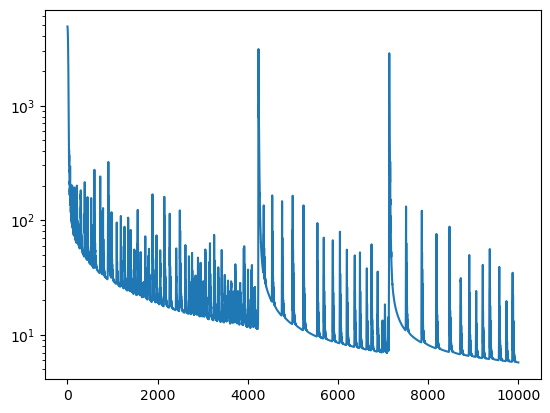

In [6]:
fig,ax = plt.subplots()
ax.plot(train_history)
ax.set_yscale('log')

In [8]:
[x_min,y_min,z_min] = lb_xyz
[x_max,y_max,z_max] = ub_xyz

x_min = -50.0
x_max = 50.0

x = np.linspace(x_min,x_max,200).reshape(-1,1)
y = np.linspace(y_min,y_max,200).reshape(-1,1)
# y = 0.0
# z = np.linspace(z_min,z_max,50).reshape(-1,1)
z = 0.0
X,Y,Z = np.meshgrid(x,y,z)

X = X.flatten('F').reshape(-1,1)
Y = Y.flatten('F').reshape(-1,1)
Z = Z.flatten('F').reshape(-1,1)

xyz = np.hstack((X,Y,Z))
xyz_test_tensor = torch.from_numpy(xyz).float().to(device)

uvwp = model_PINN.forward(xyz_test_tensor).cpu().detach().numpy()

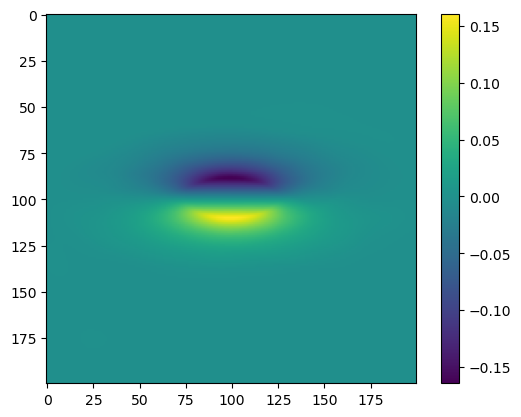

In [9]:
fig,ax = plt.subplots()
im = ax.imshow(uvwp[:,1].reshape(200,200)/1000)
fig.colorbar(im)

Text(0, 0.5, '$y$ (mm)')

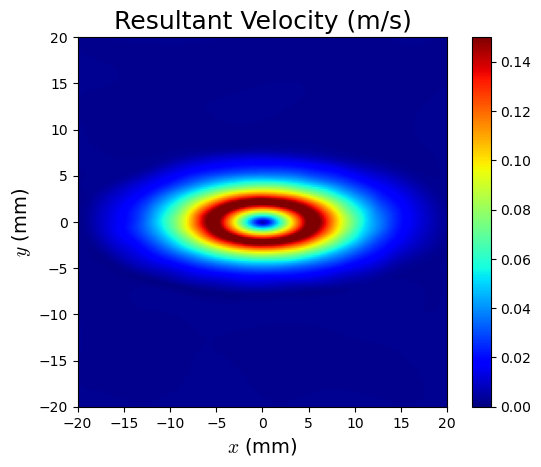

In [10]:
r_vel = np.sqrt(np.square(uvwp[:,0])+np.square(uvwp[:,1])+np.square(uvwp[:,2]))
# r_vel = np.sqrt(np.square(uvwp[:,2]))
# r_vel = uvwp[:,2]
fig,ax = plt.subplots()
im = ax.imshow((r_vel/1000).reshape(200,200),cmap = 'jet',extent = [-20,20,-20,20],vmax = 0.15,vmin = 0)
fig.colorbar(im)
ax.set_title('Resultant Velocity (m/s)',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 14)
ax.set_ylabel('$y$ (mm)',math_fontfamily = 'cm',fontsize = 14)
# plt.savefig('Res_vel_xy_Proposal.svg',format = 'svg',bbox_inches = 'tight')

ValueError: cannot reshape array of size 40000 into shape (50,200)

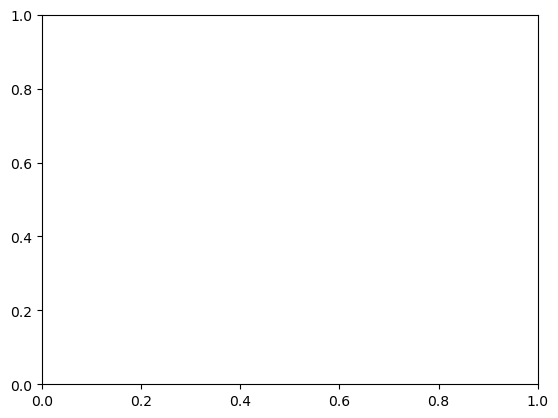

In [11]:
#Cross Section
r_vel = np.sqrt(np.square(uvwp[:,0])+np.square(uvwp[:,1])+np.square(uvwp[:,2]))
# r_vel = np.sqrt(np.square(uvwp[:,2]))
# r_vel = uvwp[:,2]
fig,ax = plt.subplots()
im = ax.imshow((np.flip(r_vel)/1000).reshape(50,200),cmap = 'jet',extent = [-20,20,-3,0],vmax = 0.15,vmin = 0)
# fig.colorbar(im)
# ax.set_title('Resultant Velocity (m/s)',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 14)
ax.set_ylabel('$z$ (mm)',math_fontfamily = 'cm',fontsize = 14)
# plt.savefig('Res_vel_xz_Proposal.svg',format = 'svg',bbox_inches = 'tight')

In [12]:
g = xyz_test_tensor.clone()
g.requires_grad = True

out_full = model_PINN.forward(g.to(device)).cpu() 
u = out_full[:,0:1]
v = out_full[:,1:2]
w = out_full[:,2:3]
p = out_full[:,3:4]
T = out_full[:,4:5]

# print(T.shape)
# T = model_PINN.PINN_T.forward(g.to(device)).cpu()

# p_xyz = autograd.grad(p,g,torch.ones([xyz_coll.shape[0], 1]).to(device), retain_graph=True, create_graph=True,allow_unused = True)[0]
u_xyz = autograd.grad(u,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()
v_xyz = autograd.grad(v,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()
w_xyz = autograd.grad(w,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()

eps2_11 = torch.square(1/2*(2*u_xyz[:,0]))
eps2_12 = torch.square(1/2*(u_xyz[:,1] + v_xyz[:,0]))
eps2_13 = torch.square(1/2*(u_xyz[:,2] + w_xyz[:,0]))

eps2_21 = eps2_12
eps2_22 = torch.square(1/2*(2*v_xyz[:,1])) 
eps2_23 = torch.square(1/2*(v_xyz[:,2] + w_xyz[:,1]))

eps2_31 = eps2_13
eps2_32 = eps2_23 
eps2_33 = torch.square(1/2*(2*w_xyz[:,2]))

eps_e = torch.sqrt((2/3)*(eps2_11 + eps2_12 + eps2_13 + eps2_21 + eps2_22 + eps2_23 + eps2_31 + eps2_32 + eps2_33)).reshape(-1,1)


# Z = eps_e*torch.exp(E_a/(R*T))
# log_Z = torch.log(eps_e) + E_a/(R*T)
log_Z = torch.log(eps_e) + E_a/(R*T) #Simplification


W = (log_Z - log_A)/n



# sigma_e =  (1/alpha_sig)*torch.asinh(W) 
sigma_e = (1/alpha_sig)*(np.log(2)/n + W) #Approximation

#____________________________#
mu_vis = sigma_e/(3*eps_e)


eps_e = eps_e.cpu().detach().numpy()
sigma_e = sigma_e.cpu().detach().numpy()
mu_vis = mu_vis.cpu().detach().numpy()


In [13]:
torch.max(T)

tensor(764.1288, grad_fn=<MaxBackward1>)

Text(0, 0.5, '$y$ (mm)')

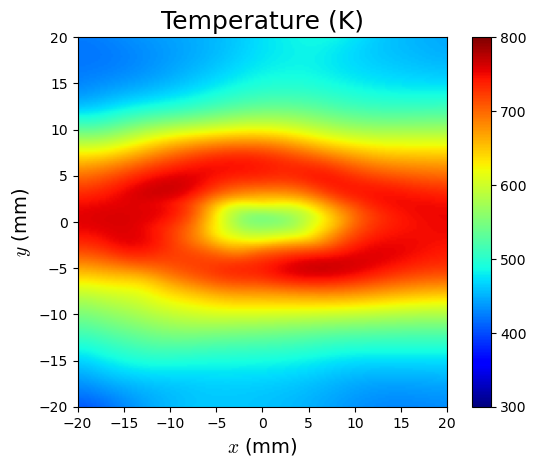

In [15]:
fig,ax = plt.subplots()
im = ax.imshow(T.cpu().detach().numpy().reshape(200,200),cmap = 'jet',extent = [-20,20,-20,20],vmax = 800,vmin = 300)
fig.colorbar(im)
ax.set_title('Temperature (K)',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 14)
ax.set_ylabel('$y$ (mm)',math_fontfamily = 'cm',fontsize = 14)
# plt.savefig('Temp_xy_Proposal.svg',format = 'svg',bbox_inches = 'tight')

ValueError: cannot reshape array of size 40000 into shape (50,200)

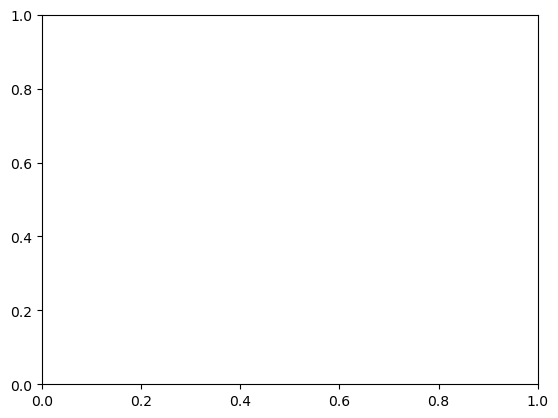

In [12]:
fig,ax = plt.subplots()
im = ax.imshow(np.flip(T.cpu().detach().numpy().reshape(50,200)),cmap = 'jet',extent = [-20,20,-3,0],vmax = 800,vmin = 300)
# fig.colorbar(im)
# ax.set_title('Temperature (K)',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 14)
ax.set_ylabel('$z$ (mm)',math_fontfamily = 'cm',fontsize = 14)
plt.savefig('Temp_xz_Proposal.svg',format = 'svg',bbox_inches = 'tight')

In [ ]:
fig,ax = plt.subplots()
im = ax.imshow(eps_e.reshape(200,200),cmap = 'jet',extent = [-20,20,-20,20],vmax = 175,vmin = 0)
fig.colorbar(im)
ax.set_title('Effective Strain Rate ($s^{-1}$)',math_fontfamily = 'cm',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 16)
ax.set_ylabel('$y$ (mm)',math_fontfamily = 'cm',fontsize = 16)
# plt.savefig('Viscosity_Feb7.svg',format = 'svg',bbox_inches = 'tight')
# plt.savefig('Strain_Rate_xy_Proposal.svg',format = 'svg',bbox_inches = 'tight')

NameError: name 'plt' is not defined

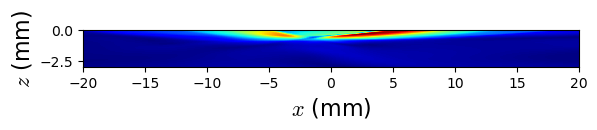

In [ ]:
fig,ax = plt.subplots()
im = ax.imshow(np.flip(eps_e.reshape(50,200)),cmap = 'jet',extent = [-20,20,-3,0],vmax = 175,vmin = 0)
# fig.colorbar(im)
# ax.set_title('$\dot\epsilon_e$ ($s^{-1}$)',math_fontfamily = 'cm',fontsize = 18)
ax.set_xlabel('$x$ (mm)',math_fontfamily = 'cm',fontsize = 16)
ax.set_ylabel('$z$ (mm)',math_fontfamily = 'cm',fontsize = 16)
# plt.savefig('Viscosity_Feb7.svg',format = 'svg',bbox_inches = 'tight')
plt.savefig('Strain_Rate_xz_Proposal.svg',format = 'svg',bbox_inches = 'tight')

In [ ]:
np.min(eps_e)

0.141188

In [ ]:
#Testing with FVM data
fvm_data = loadmat('/home/smartlab/Documents/jupyterNB/raghav/Projects_git_summer2024/Data/AFSD_Nikhil/Exponential_300_2mms.mat')

u_fvm = fvm_data['u_star']
v_fvm = fvm_data['v_star']
w_fvm = fvm_data['w_star']

u_fvm = (u_fvm[0:-1,:,:] + u_fvm[1:,:,:])/2
v_fvm = (v_fvm[:,0:-1,:] + v_fvm[:,1:,:])/2
w_fvm = (w_fvm[:,:,0:-1] + w_fvm[:,:,1:])/2


Res_v_fvm = np.sqrt(np.square(u_fvm) + np.square(v_fvm) + np.square(w_fvm))
T_fvm = fvm_data['T']
sigma_e_fvm = fvm_data['effectivestress']

/home/smartlab/anaconda3/envs/raghav/lib/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [ ]:
fvm_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'ABC', 'ALPHA', 'Db', 'De', 'Dn', 'Ds', 'Dt', 'Dw', 'Dx', 'Dy', 'Dz', 'FL', 'Fb', 'Fe', 'Fn', 'Fs', 'Ft', 'Fw', 'None', 'Lx', 'Ly', 'Lz', 'N', 'Nx', 'Ny', 'Nz', 'RPS', 'SZ', 'T', 'Tb', 'Te', 'Theat', 'Tn', 'Told', 'Ts', 'Tt', 'Tw', 'X', 'Xcenter', 'Y', 'Ycenter', 'Z', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'aB', 'aE', 'aN', 'aP', 'aS', 'aT', 'aW', 'alpha', 'alpha4', 'alpha5', 'alpha6', 'alphaP', 'alphaU', 'ans', 'b1', 'b2', 'ba', 'c', 'c1', 'c2', 'c3', 'd_u', 'd_v', 'd_w', 'delta', 'delta1', 'dx', 'dy', 'dz', 'eexx', 'eeyy', 'eezz', 'effectivestress', 'effstrrate', 'ep', 'ep1', 'errorheat', 'errormax', 'exp1', 'hbo', 'heat', 'hup', 'i', 'imax', 'ite', 'itera', 'iteration', 'j', 'jmax', 'k', 'k1', 'k2', 'k3', 'kmax', 'ku', 'l', 'maxRes', 'maxRes_u', 'maxRes_v', 'maxRes_w', 'mu', 'mumax', 'p', 'pB', 'pE', 'pN', 'pP', 'pRes', 'pS', 'pT', 'pW', 'p_prime', 'p_star', 'plasticheat', 'pold', 'pressure_term', 'q', 'q1', 'q2', 'q3', 'qu', 'ro',

In [ ]:
[x_min,y_min,z_min] = lb_xyz
[x_max,y_max,z_max] = ub_xyz

# x_min = -20.0
# x_max = 20.0

# x = np.linspace(x_min,x_max,250)
x = np.linspace(x_min,x_max,251)
x = (x[0:-1] + x[1:]).reshape(-1,1)/2
y = np.linspace(y_min,y_max,101)
y = (y[0:-1] + y[1:]).reshape(-1,1)/2
z = np.linspace(z_min,z_max,13)
z = (z[0:-1] + z[1:]).reshape(-1,1)/2

X,Y,Z = np.meshgrid(x,y,z)

X = X.flatten('F').reshape(-1,1)
Y = Y.flatten('F').reshape(-1,1)
Z = Z.flatten('F').reshape(-1,1)

xyz = np.hstack((X,Y,Z))
xyz_test_tensor = torch.from_numpy(xyz).float().to(device1)

uvwp = model_PINN.PINN_uvw.forward(xyz_test_tensor).cpu().detach().numpy()

Res_v_PINN = np.sqrt(np.square(uvwp[:,0])+np.square(uvwp[:,1])+np.square(uvwp[:,2])).reshape(12,250,100,order = 'C')

Res_v_PINN = np.swapaxes(np.swapaxes(Res_v_PINN,0,1),1,2)/1000

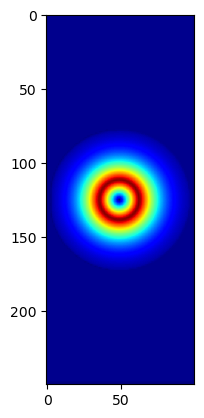

In [ ]:
plt.imshow(Res_v_fvm[:,:,11],cmap = 'jet')

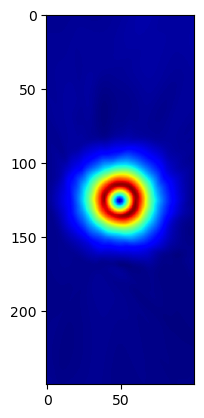

In [ ]:
plt.imshow(Res_v_PINN[:,:,11],cmap = 'jet')

In [ ]:
RE = np.linalg.norm((Res_v_PINN-Res_v_fvm).reshape(-1,),2)/np.linalg.norm(Res_v_fvm.reshape(-1,),2)
print(RE)

0.43992511093364783


In [ ]:
RMSE = np.sqrt(np.mean(np.square(Res_v_fvm[:]-Res_v_PINN[:])))
print(RMSE)

0.0056141700274422056


In [ ]:
g = xyz_test_tensor.clone()
g.requires_grad = True

out_full = model_PINN.forward(g.to(device)).cpu() 
u = out_full[:,0:1]
v = out_full[:,1:2]
w = out_full[:,2:3]
p = out_full[:,3:4]
T = out_full[:,4:5]


# print(T.shape)
# T = model_PINN.forward(g.to(device)).cpu()

# p_xyz = autograd.grad(p,g,torch.ones([xyz_coll.shape[0], 1]).to(device), retain_graph=True, create_graph=True,allow_unused = True)[0]
u_xyz = autograd.grad(u,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()
v_xyz = autograd.grad(v,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()
w_xyz = autograd.grad(w,g,torch.ones([xyz_test_tensor.shape[0], 1]).to('cpu'),retain_graph=True,allow_unused = True)[0].cpu()

eps2_11 = torch.square(1/2*(2*u_xyz[:,0]))
eps2_12 = torch.square(1/2*(u_xyz[:,1] + v_xyz[:,0]))
eps2_13 = torch.square(1/2*(u_xyz[:,2] + w_xyz[:,0]))

eps2_21 = eps2_12
eps2_22 = torch.square(1/2*(2*v_xyz[:,1])) 
eps2_23 = torch.square(1/2*(v_xyz[:,2] + w_xyz[:,1]))

eps2_31 = eps2_13
eps2_32 = eps2_23 
eps2_33 = torch.square(1/2*(2*w_xyz[:,2]))

eps_e = torch.sqrt((2/3)*(eps2_11 + eps2_12 + eps2_13 + eps2_21 + eps2_22 + eps2_23 + eps2_31 + eps2_32 + eps2_33)).reshape(-1,1)


# Z = eps_e*torch.exp(E_a/(R*T))
# log_Z = torch.log(eps_e) + E_a/(R*T)
log_Z = torch.log(eps_e) + E_a/(R*T) #Simplification


W = (log_Z - log_A)/n



# sigma_e =  (1/alpha_sig)*torch.asinh(W) 
sigma_e = (1/alpha_sig)*(np.log(2)/n + W) #Approximation

#____________________________#
mu_vis = sigma_e/(3*eps_e)


eps_e = eps_e.cpu().detach().numpy()
sigma_e = sigma_e.cpu().detach().numpy()
mu_vis = mu_vis.cpu().detach().numpy()


In [ ]:
T_PINN = T.cpu().detach().numpy().reshape(12,250,100,order = 'C')
T_PINN = np.swapaxes(np.swapaxes(T_PINN,0,1),1,2)

print("RE: ",np.linalg.norm((T_PINN-T_fvm).reshape(-1,),2)/np.linalg.norm(T_fvm.reshape(-1,),2))
print("RMSE: ",np.sqrt(np.mean(np.square(T_fvm[:]-T_PINN[:]))))

RE:  0.0661861823040817
RMSE:  35.78858208607823


In [ ]:
#Correlation between Predicted and Actual 
np.corrcoef(T_PINN.reshape(-1,),T_fvm.reshape(-1,))

array([[1.        , 0.96506005],
       [0.96506005, 1.        ]])

In [ ]:
np.corrcoef(Res_v_PINN.reshape(-1,),Res_v_fvm.reshape(-1,))

array([[1.        , 0.89007729],
       [0.89007729, 1.        ]])

In [ ]:
eps_e = eps_e.reshape(12,250,100,order = 'C')
eps_e = np.swapaxes(np.swapaxes(eps_e,0,1),1,2)

eps_e_fvm = fvm_data['effstrrate']
np.corrcoef(eps_e.reshape(-1,),eps_e_fvm.reshape(-1,))

array([[1.        , 0.89403772],
       [0.89403772, 1.        ]])

In [ ]:
print("RE: ",np.linalg.norm((eps_e-eps_e_fvm).reshape(-1,),2)/np.linalg.norm(eps_e_fvm.reshape(-1,),2))
print("RMSE: ",np.sqrt(np.mean(np.square(eps_e_fvm[:]-eps_e[:]))))

RE:  1.591256496056418
RMSE:  9.22296692410567
